## **SIMULACIÓN | ENTREGABLE 1**
### ***HMM - Hidden Markov's Model para Análisis de Sentimientos***
[Aquí insertar participantes, descripción, objetivos y alcance]

In [141]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display         # Librería IPython: Mostrar datos en Jupyter Notebook
from hmmlearn.hmm import CategoricalHMM

In [142]:
df_FlexDrive_Emotions = pd.read_csv('../../../docs/poblaciones/dfFlexDrive_Cundiboyacense.csv', sep=';', encoding='utf-8')

## Definición: Distribución Inicial (π) para todo DF

C:\Users\leshi\AppData\Local\Temp\ipykernel_49116\1307662081.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["E", "Ne", "N", "Ni", "I"], y=distribucion, palette="viridis")


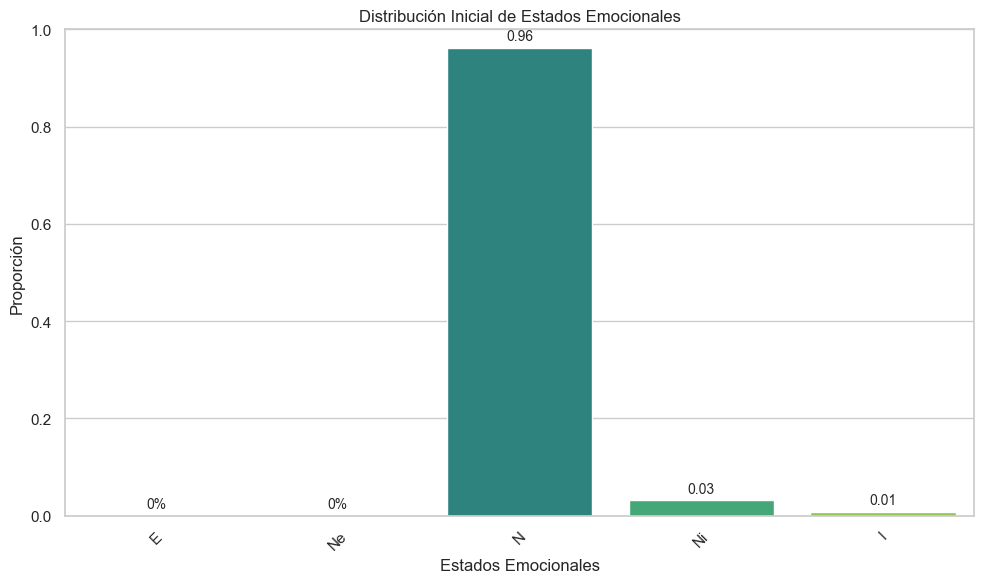

Distribución inicial: [0, 0, 0.9612403100775194, 0.031007751937984492, 0.007751937984496124]


In [143]:
def contiene(x, *valores):
    return all(v in x.split(';') for v in valores if isinstance(x, str))
    
def calcular_distribucion_inicial(df):
    len_df = len(df)
    
    # Inicializar distribución: E, Ne, N, Ni, I
    distribucion = [0, 0, 0, 0, 0]

    # Sanciones NI (Neutro-Indiferente)
    distribucion[3] += df["P4-Ciudad"].isna().sum() / len_df
    distribucion[3] += df["P7-Actividad_Actual_Multi"].isna().sum() / len_df

    # Estudiante de secundaria y universitario
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Universitario")).sum() / len_df
    # Empleado y desempleado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Empleado", "Desempleado")).sum() / len_df
    # Est. secundaria y desempleado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Desempleado")).sum() / len_df
    # Est. secundaria y jubilado
    distribucion[3] += df["P7-Actividad_Actual_Multi"].apply(lambda x: contiene(x, "Estudiante de secundaria", "Jubilado")).sum() / len_df

    # Edad temprana + Jubilado
    mask_edad_jubilado = (
        df["P2-Edad"].isin(["16-17", "18-25"]) &
        df["P7-Actividad_Actual_Multi"].fillna("").str.contains("Jubilado")
    )
    distribucion[3] += mask_edad_jubilado.sum() / len_df

    # Incoherencia: usa y no usa servicios públicos
    mask_p10_vs_p9 = (
        df["P10-Servicios_Públicos_Usados_Multi"].notna() &
        (df["P9-Frecuencia_Uso_Servicios_Públicos"] == "En ninguna ocasión.")
    )
    
    distribucion[4] += mask_p10_vs_p9.sum() / len_df  # I

    # Estado N = complemento
    distribucion[2] = 1 - sum(distribucion)

    # Visualización
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=["E", "Ne", "N", "Ni", "I"], y=distribucion, palette="viridis")

    # Etiquetas
    plt.title("Distribución Inicial de Estados Emocionales")
    plt.xlabel("Estados Emocionales")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45)

    # Valores encima de barras
    for i, v in enumerate(distribucion):
        etiqueta = f"{v:.2f}" if v > 0 else "0%"
        plt.text(i, v + 0.01, etiqueta, ha='center', va='bottom', fontsize=10)

    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    # Mostrar el array final
    print(f"Distribución inicial: {distribucion}")
    return np.array(distribucion)

# Calcular
distribucion_inicial = calcular_distribucion_inicial(df_FlexDrive_Emotions)


## Seguimiento: Pesos de Emociones y Asignación por Filas

In [144]:
# Puntaje y clasificación para conceptos positivos
def puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros=False):
    if pd.isna(respuesta):
        return 0.0
    pesos = pesos_con_otros if usar_otros else pesos_estandar
    opciones = [op.strip() for op in respuesta.split(';')]
    return sum(pesos.get(op, 0.0) for op in opciones)


def clasificar_estado(score):
    if score >= 0.75:
        return "E"   # Entusiasta
    elif score >= 0.55:
        return "Ne"  # Neutro-Entusiasta
    elif score >= 0.40:
        return "N"   # Neutral
    elif score >= 0.20:
        return "Ni"  # Neutro-Indiferente
    else:
        return "I"   # Indiferente


# Aplica a cada fila del DataFrame
def procesar_fila_DF(df, columna, pesos_estandar, pesos_con_otros):
    
    respuesta = df[columna]
    usar_otros = "Otro" in str(respuesta)
    
    if pd.isna(respuesta) or "No hay beneficios" in str(respuesta):
        score = 0.0
    else:
        score = puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros)
    
    estado = clasificar_estado(score)
    return pd.Series({f"score_{columna[:3]}": round(score, 3), f"estado_{columna[:3]}": estado})

In [145]:
# Puntaje y clasificación para conceptos positivos
def puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros=False):
    if pd.isna(respuesta):
        return 0.0
    pesos = pesos_con_otros if usar_otros else pesos_estandar
    opciones = [op.strip() for op in respuesta.split(';')]
    return sum(pesos.get(op, 0.0) for op in opciones)


def clasificar_estado_NEG(score):
    if score >= 0.80:
        return "I"   # Entusiasta
    elif score >= 0.60:
        return "Ni"  # Neutro-Entusiasta
    elif score >= 0.45:
        return "N"   # Neutral
    elif score >= 0.25:
        return "Ne"  # Neutro-Indiferente
    else:
        return "E"   # Indiferente


# Aplica a cada fila del DataFrame
def procesar_fila_DF_NEG(df, columna, pesos_estandar, pesos_con_otros):
    
    respuesta = df[columna]
    usar_otros = "Otro" in str(respuesta)
    
    if pd.isna(respuesta) or "No hay beneficios" in str(respuesta):
        score = 1.0
    else:
        score = puntaje_FORM1(respuesta, pesos_estandar, pesos_con_otros, usar_otros)
    
    estado = clasificar_estado_NEG(score)
    return pd.Series({f"score_{columna[:3]}": round(score, 3), f"estado_{columna[:3]}": estado})

## Análisis: P21 (Beneficios P2P) [3 casos]
[Aquí la descripción del caso. Incluye ESTÁNDAR, OTROS, NINGUNO]

In [146]:
# Pesos por opción (caso 1)
pesos_estandar = {
    "Posibilidad de generar ingresos como propietario del vehículo": 0.223,
    "Mayor flexibilidad en horarios": 0.152,
    "Diversidad de vehículos para rentar / arrendar": 0.151,
    "Aprovechamiento de vehículos particulares inactivos": 0.174,
    "Promueve la economía colaborativa": 0.101,
    "Mejor negociación en condiciones de arriendo": 0.126,
    "Experiencia de negocio más personalizada": 0.072
}

# Pesos con "Otros" incluidos (caso 2)
pesos_con_otros = {
    "Posibilidad de generar ingresos como propietario del vehículo": 0.202,
    "Mayor flexibilidad en horarios": 0.138,
    "Diversidad de vehículos para rentar / arrendar": 0.137,
    "Aprovechamiento de vehículos particulares inactivos": 0.158,
    "Promueve la economía colaborativa": 0.092,
    "Mejor negociación en condiciones de arriendo": 0.115,
    "Experiencia de negocio más personalizada": 0.065,
    "Otro: Acceso a un vehículo sin poseerlo": 0.093
}

# Aplicar al DataFrame
df_FlexDrive_Emotions[["score_P21", "estado_P21"]] = df_FlexDrive_Emotions.apply(
    lambda fila: procesar_fila_DF(fila, "P21-Beneficios_P2P", pesos_estandar, pesos_con_otros),
    axis=1
)


# Vista previa del resultado
display(df_FlexDrive_Emotions[["P21-Beneficios_P2P", "score_P21", "estado_P21"]])

,P21-Beneficios_P2P,score_P21,estado_P21
0,Mayor flexibilidad en horarios;Experiencia de ...,0.325,Ni
1,Mayor flexibilidad en horarios;Posibilidad de ...,0.549,N
2,Aprovechamiento de vehículos particulares inac...,0.326,Ni
3,Aprovechamiento de vehículos particulares inac...,0.275,Ni
4,Posibilidad de generar ingresos como propietar...,0.649,Ne
...,...,...,...
382,NaN,0.000,I
383,Promueve la economía colaborativa,0.101,I
384,Experiencia de negocio más personalizada,0.072,I
385,Posibilidad de generar ingresos como propietar...,0.650,Ne


## Análisis: P22 (Desventajas P2P) [3 casos]
[Aquí la descripción del caso. Incluye ESTÁNDAR, OTROS, NINGUNO]

In [147]:
# Pesos por opción (caso 1)
pesos_estandar = {
    'Posibles daños o mal uso del vehículo rentado' : 0.310049019607843,
    'Desconfianza frente a clientes / personas desconocidas' : 0.225490196078431,
    'Posible uso de vehículos para fines no autorizados' : 0.196078431372549,
    'Falta de regulación por parte de entidades oficiales' : 0.139705882352941,
    'Falta de control en la entrega o devolución del vehículo' : 0.128676470588235,
}

# Pesos con "Otros" incluidos (caso 2)
pesos_con_otros = {
    'Posibles daños o mal uso del vehículo rentado' : 0.268,
    'Desconfianza frente a clientes / personas desconocidas' : 0.195,
    'Posible uso de vehículos para fines no autorizados' : 0.17,
    'Falta de regulación por parte de entidades oficiales' : 0.123,
    'Falta de control en la entrega o devolución del vehículo' : 0.111,
    'Otros: Informalidad laboral': 0.133,
    }

# Aplicar al DataFrame
df_FlexDrive_Emotions[["score_P22", "estado_P22"]] = df_FlexDrive_Emotions.apply(
    lambda fila: procesar_fila_DF_NEG(fila, "P22-Desventajas_P2P", pesos_estandar, pesos_con_otros),
    axis=1
)

# Vista previa del resultado
display(df_FlexDrive_Emotions[["P22-Desventajas_P2P", "score_P22", "estado_P22"]])

,P22-Desventajas_P2P,score_P22,estado_P22
0,Posibles daños o mal uso del vehículo rentado;...,0.450,Ne
1,Posibles daños o mal uso del vehículo rentado;...,0.646,Ni
2,Posibles daños o mal uso del vehículo rentado;...,0.664,Ni
3,Posibles daños o mal uso del vehículo rentado;...,0.506,N
4,Desconfianza frente a clientes / personas desc...,1.000,I
...,...,...,...
382,NaN,1.000,I
383,Posibles daños o mal uso del vehículo rentado,0.310,Ne
384,Falta de control en la entrega o devolución de...,0.439,Ne
385,Posibles daños o mal uso del vehículo rentado;...,0.871,I


In [148]:
# Conteo estado_P21 y estado_P22
conteo_estados = df_FlexDrive_Emotions[['estado_P21', 'estado_P22']].apply(pd.Series.value_counts).sort_values(by="estado_P21").fillna(0)
conteo_estados = conteo_estados.astype(int)
# Mostrar conteo de estados
print("\nConteo de estados emocionales:")
display(conteo_estados)



Conteo de estados emocionales:


,estado_P21,estado_P22
E,12,66
Ne,30,95
N,69,47
Ni,125,77
I,151,102


## Asignación por dependencia del estado P22 a P21

In [149]:
def comparar_p21_p22(p21, p22):
    diferencia = p21 - p22

    if diferencia > 0.20:
        return "E"
    elif diferencia > 0.05:
        return "Ne"
    elif abs(diferencia) <= 0.05:
        return "N"
    elif diferencia < -0.05:
        if diferencia >= -0.25:
            return "Ni"
        else:
            return "I"


df_FlexDrive_Emotions["estado_comb_P21_P22"] = df_FlexDrive_Emotions.apply(
    lambda fila: comparar_p21_p22(fila["score_P21"], fila["score_P22"]),
    axis=1
)

# Conteo de estados combinados
df_FlexDrive_Emotions["estado_comb_P21_P22"].value_counts().sort_index()

estado_comb_P21_P22
E      14
I     152
N      55
Ne     21
Ni    145
Name: count, dtype: int64

## Análisis: P32 (Interés en ser propietario) con relación a P13 (Posee vehículo)

In [ ]:
def evaluar_coherencia_emocion(fila):

    tiene_vehiculo = fila["P13-Posee_Veh_Propio"] == 1
    quiere_ser_prop = fila["P32-Interés_Propietario"] == 1
    
    # Inicializar valores
    coherencia = "Normal"
    emocion = None
    
    if tiene_vehiculo and quiere_ser_prop:
        # Caso 1: tiene vehículo y quiere ser propietario
        coherencia = "Alta"
        emocion = "Entusiasta"
    elif tiene_vehiculo and not quiere_ser_prop:
        # Caso 2: tiene vehículo y NO quiere ser propietario
        coherencia = "Alta"
        emocion = "Neutral"
    elif not tiene_vehiculo and quiere_ser_prop:
        # Caso 3: no tiene vehículo pero quiere ser propietario
        coherencia = "Baja"
        emocion = None
    else:
        # Caso 4: no tiene vehículo y no quiere ser propietario
        coherencia = "Normal"
        emocion = None

    return pd.Series({
        "coherencia_P13_P32": coherencia,
        "emocion_P13_P32": emocion
    })

# Aplicar la función a cada fila del DataFrame
df_FlexDrive_Emotions[["coherencia_P13_P32", "emocion_P13_P32"]] = df_FlexDrive_Emotions.apply(evaluar_coherencia_emocion, axis=1)


# Mostrar el resultado
display(df_FlexDrive_Emotions[["coherencia_P13_P32", "emocion_P13_P32"]])


,coherencia_P13_P32,emocion_P13_P32
0,Baja,None
1,Alta,Entusiasta
2,Baja,None
3,Alta,Entusiasta
4,Normal,None
...,...,...
382,Normal,None
383,Alta,Entusiasta
384,Normal,None
385,Baja,None
